In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    font_scale=1.1
)

plt.rcParams.update({
    "figure.figsize": (20, 10),
    "figure.dpi": 110,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "grid.alpha": 1
})

In [2]:
train = pd.read_csv("Datasets/titanic/train.csv")
test = pd.read_csv("Datasets/titanic/tested.csv")
train.columns
test.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [3]:
X_train , y_train = train.drop(columns=['Survived']) , train['Survived']
X_test , y_test = test.drop(columns=['Survived'])    , test['Survived']


In [4]:
X_train.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699113,0.523008,0.381594,32.204208
std,257.353842,0.836071,14.526507,1.102743,0.806057,49.693429
min,1.000000,1.000000,0.416700,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:

X_train
'''

'SibSp' is no of siblings
'Parch is no of parents and children aboard titanic'

'''

X_train['mem_on_board'] = X_train['SibSp'] + X_train['Parch']
X_train
 

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,mem_on_board
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0
888,889,3,"Johnston, Miss. Catherine Helen 'Carrie'",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,3
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0


In [6]:
X_train.describe()
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
print('Cabin_null_percent',(1 - 204/891) *100 ,"%")
print('Age_null_percent',(1 - 714/891) *100 ,"%")

Cabin_null_percent 77.1043771043771 %
Age_null_percent 19.865319865319865 %


In [8]:
X_train.corrwith(y_train, method="spearman" , numeric_only=True)

PassengerId    -0.005007
Pclass         -0.339668
Age            -0.052565
SibSp           0.088879
Parch           0.138266
Fare            0.323736
mem_on_board    0.165463
dtype: float64

In [9]:
 
X_train.corrwith(y_train, method="pearson" , numeric_only=True)
# X_train[X_train['Pclass']==3]['Fare']


PassengerId    -0.005007
Pclass         -0.338481
Age            -0.077221
SibSp          -0.035322
Parch           0.081629
Fare            0.257307
mem_on_board    0.016639
dtype: float64

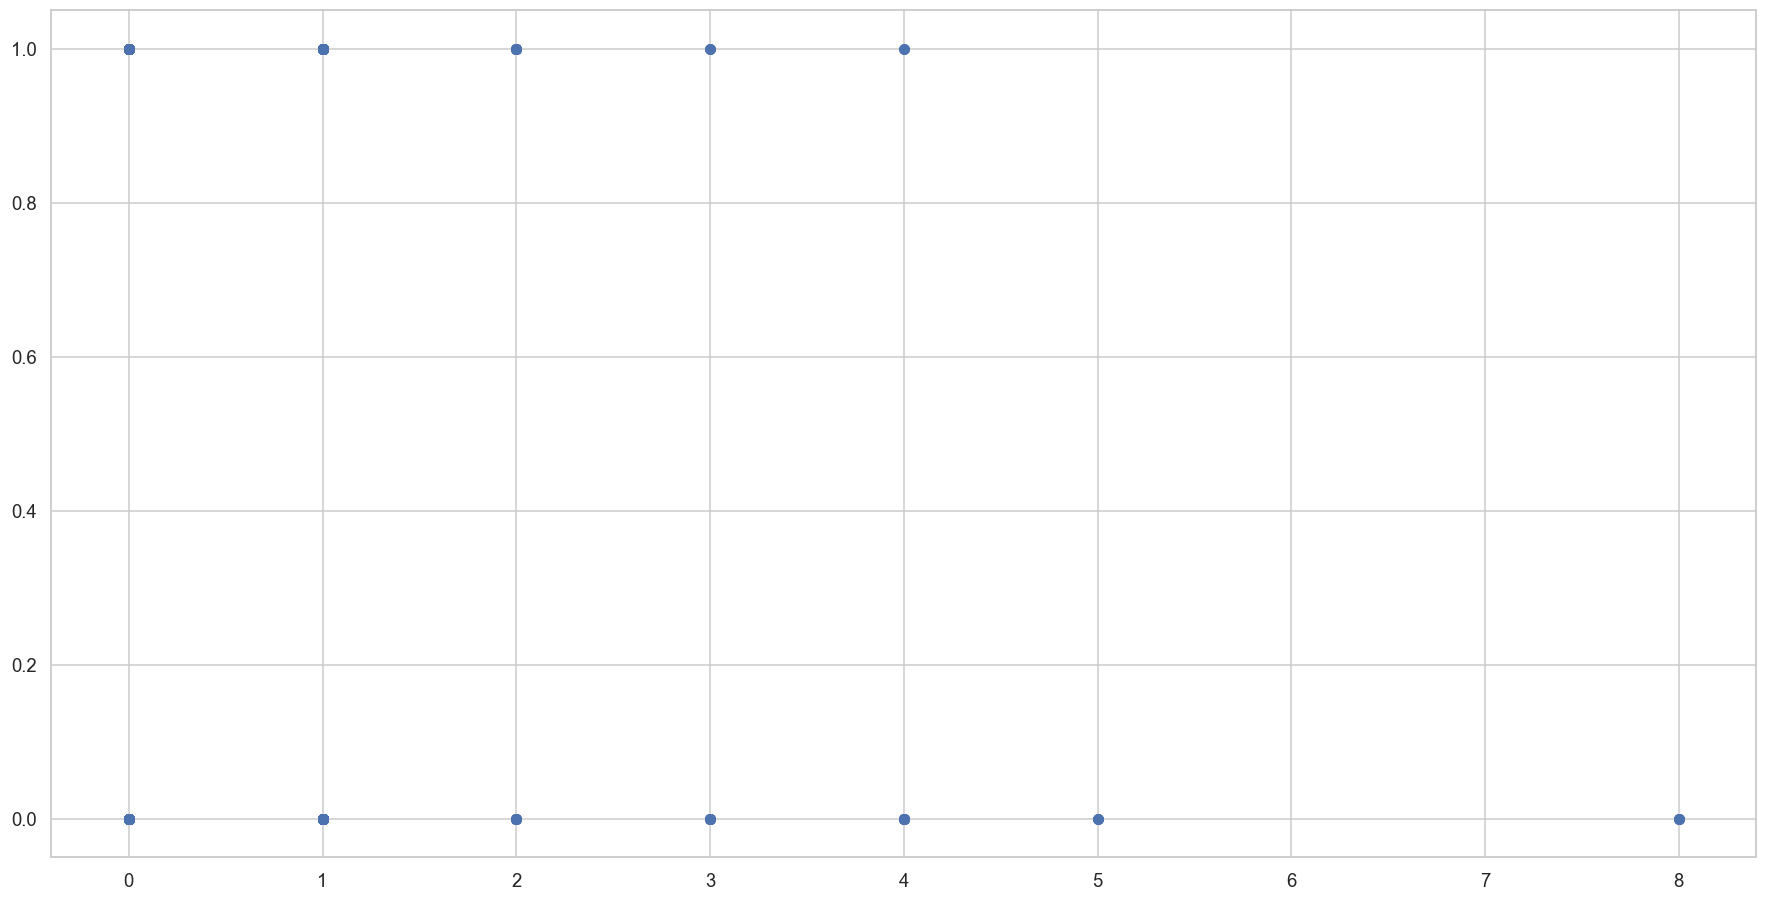

In [10]:
plt.scatter(X_train["SibSp"] , y_train )
  

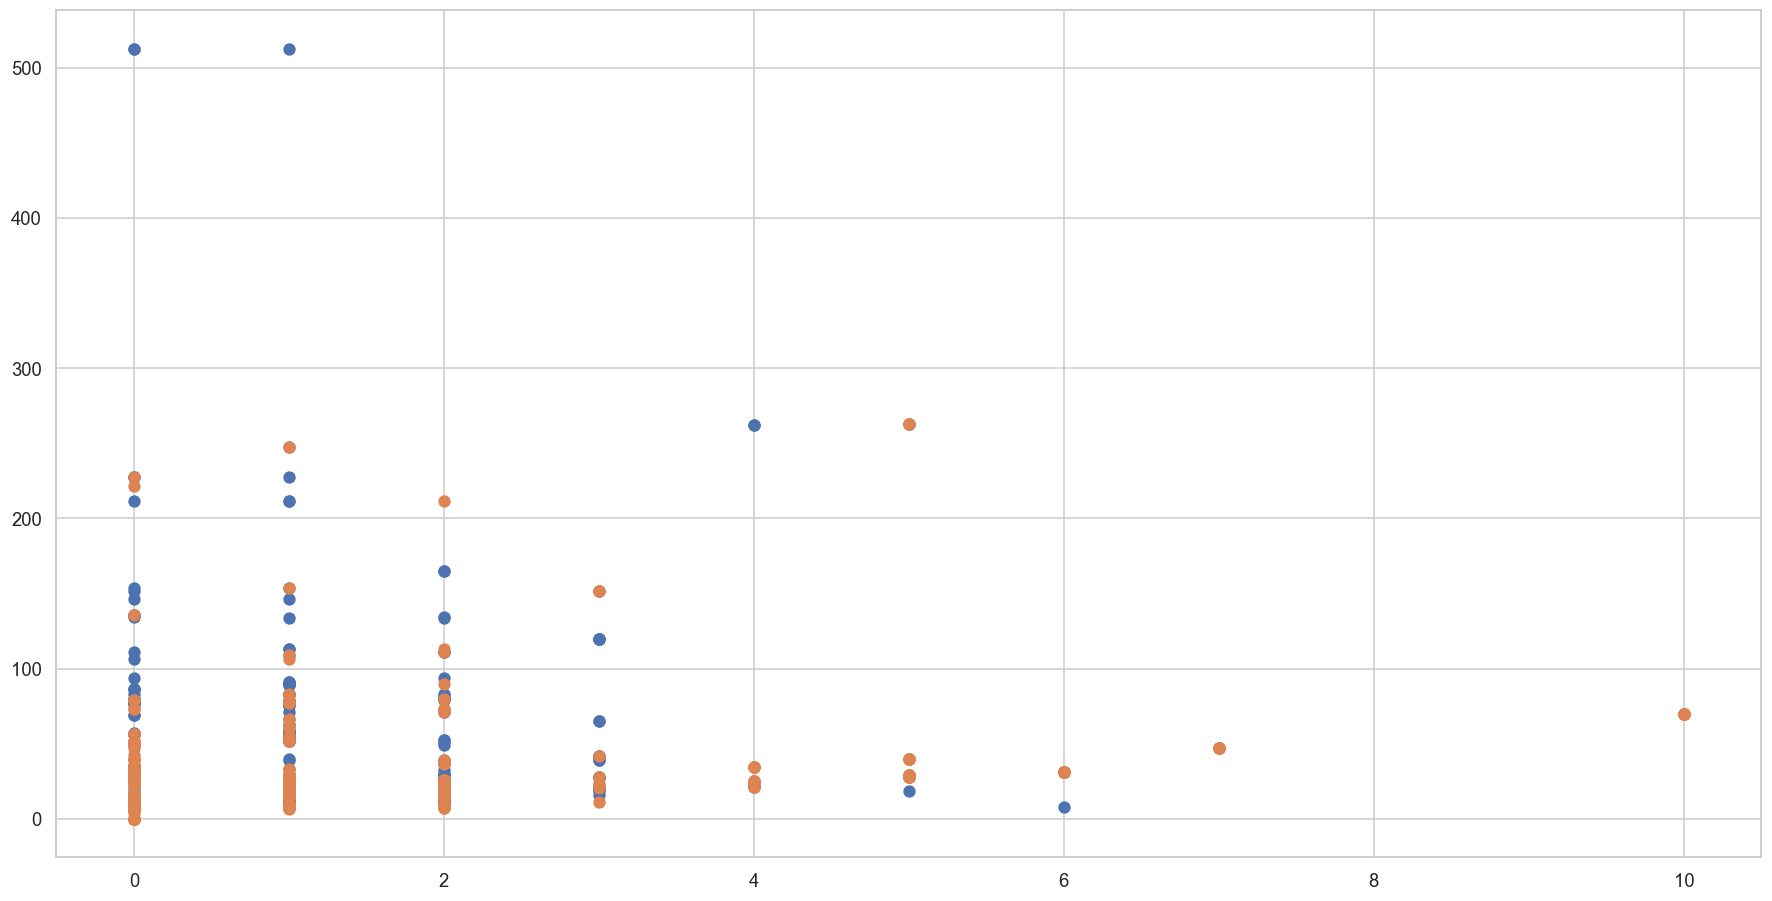

In [11]:

# sns.scatterplot(x= X_train['mem_on_board'] , y= X_train['Fare'] , hue = y_train  ,sizes=500 )
plt.scatter(x = X_train.loc[(y_train==1),'mem_on_board'] , y = X_train.loc[ (y_train==1), 'Fare'] 
            , s =50 , label = "survived")
plt.scatter(x = X_train.loc[(y_train==0),'mem_on_board'] , y = X_train.loc[ (y_train==0), 'Fare'] 
            , s =50 , label = "not_survived")
# plt.bar(X_train["Pclass"] ,y_train)
plt.show()


In [12]:

from scipy.stats import chi2_contingency
p_val = {}
for i in X_train.columns:
    ct = pd.crosstab(X_train[f'{i}'], y_train)
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
    p_val[p]  = i
    
for i in sorted(p_val):
    print( p_val[i] ,":", f"{i}" )




Sex : 1.1973570627755645e-58
Pclass : 4.549251711298793e-23
mem_on_board : 3.579668975443533e-14
Fare : 1.1647635739939964e-11
SibSp : 1.5585810465902147e-06
Embarked : 1.769922284120912e-06
Parch : 9.703526421039996e-05
Ticket : 0.011527296011637747
Age : 0.1014111101886096
Cabin : 0.18357354976388165
Name : 0.484248151973633


In [13]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
# imputer.fit_transform(X_train['Age'].to_numpy().reshape((-1,1))),


In [14]:
median_age = X_train["Age"].median()
mean_age = X_train["Age"].mean()
X_train["Age_median"] = X_train["Age"].fillna(median_age )
X_train["Age_mean"]= X_train["Age"].fillna(mean_age)

<Axes: xlabel='Age', ylabel='Count'>

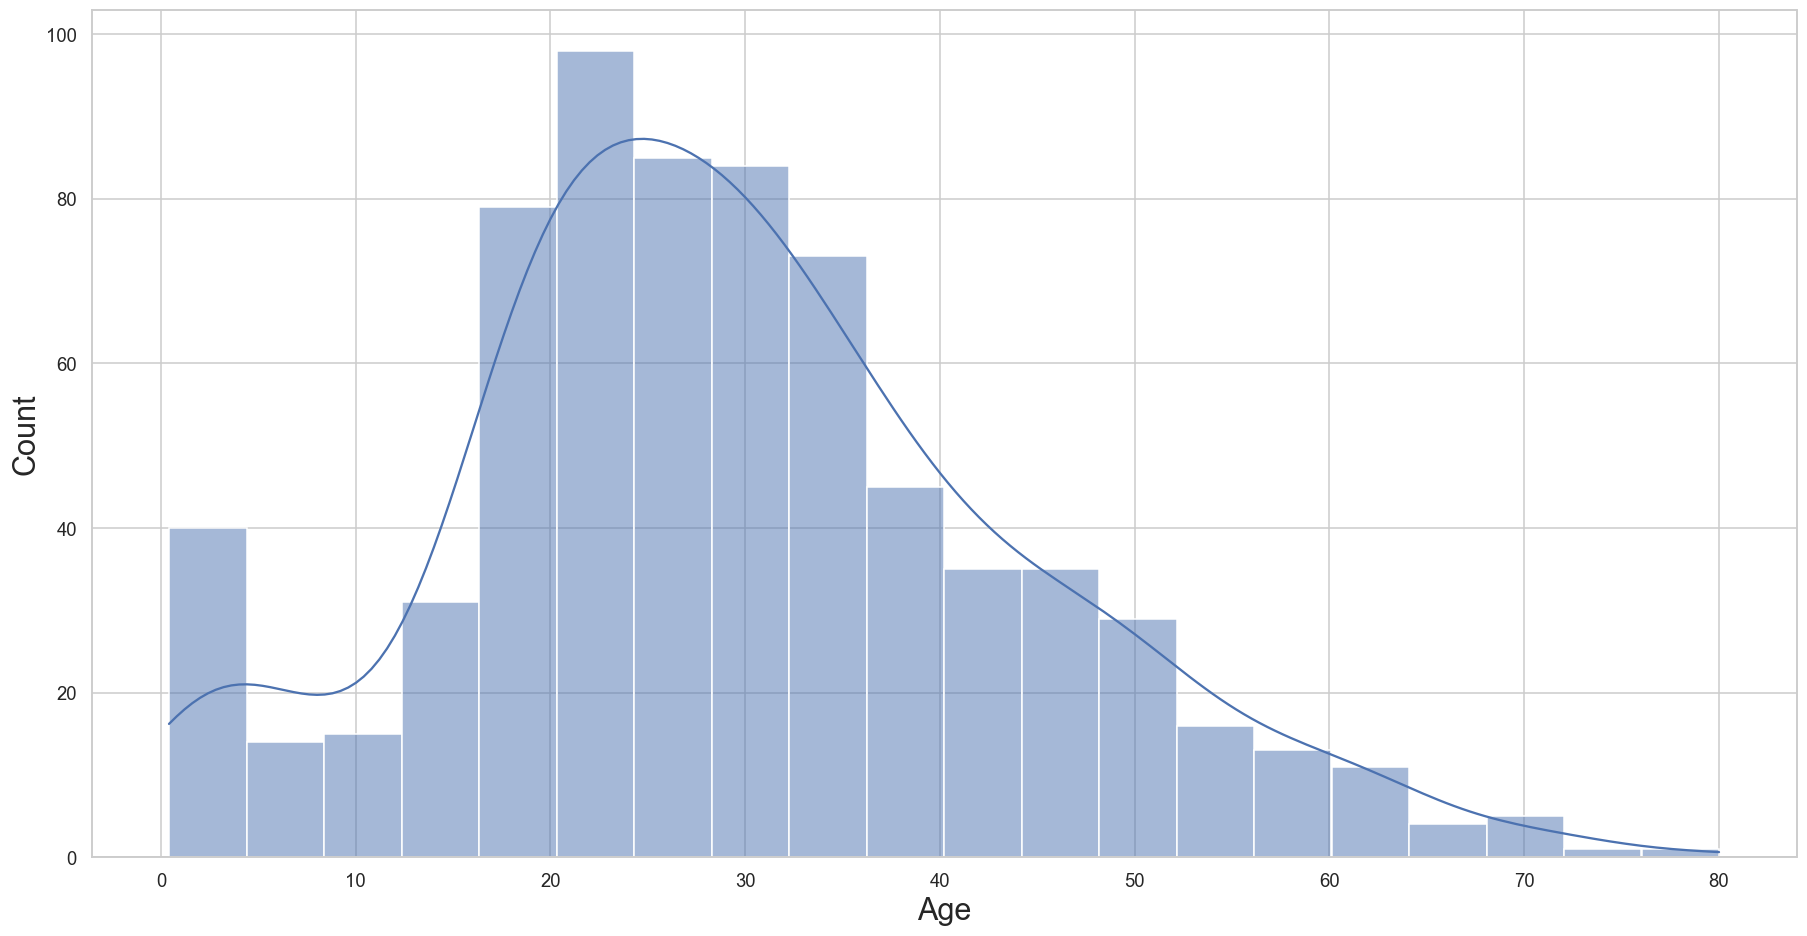

In [15]:
# sns.kdeplot(X_train['Age'])
sns.histplot((X_train['Age']) , kde=True)


In [16]:
ctable = pd.crosstab(X_train["Embarked"] , y_train)
chi2, p, dof, expected = chi2_contingency(ctable)
p

1.769922284120912e-06

In [17]:
from scipy.stats import ttest_ind

survived =     y_train==1
not_survived = y_train==0

gp1 = X_train[survived]["Age_mean"] 
gp2 = X_train[not_survived]["Age_mean"]

t_stat , pm = ttest_ind(gp1 , gp2)

gp1med = X_train[survived]["Age_median"]
gp2med = X_train[not_survived]["Age_median"]

t , pmed = ttest_ind(gp1med , gp2med)

In [18]:
print("age_median "  , pmed)
print("age_mean "  , pm)

age_median  0.05275952065419841
age_mean  0.03721625788771108


In [19]:
from scipy.stats import  f_oneway
f_st , p_fmed = f_oneway(gp1med , gp2med)
f_st , p_fm  = f_oneway(gp1 , gp2)

p_fm

0.037216257887700624

<Axes: xlabel='Fare'>

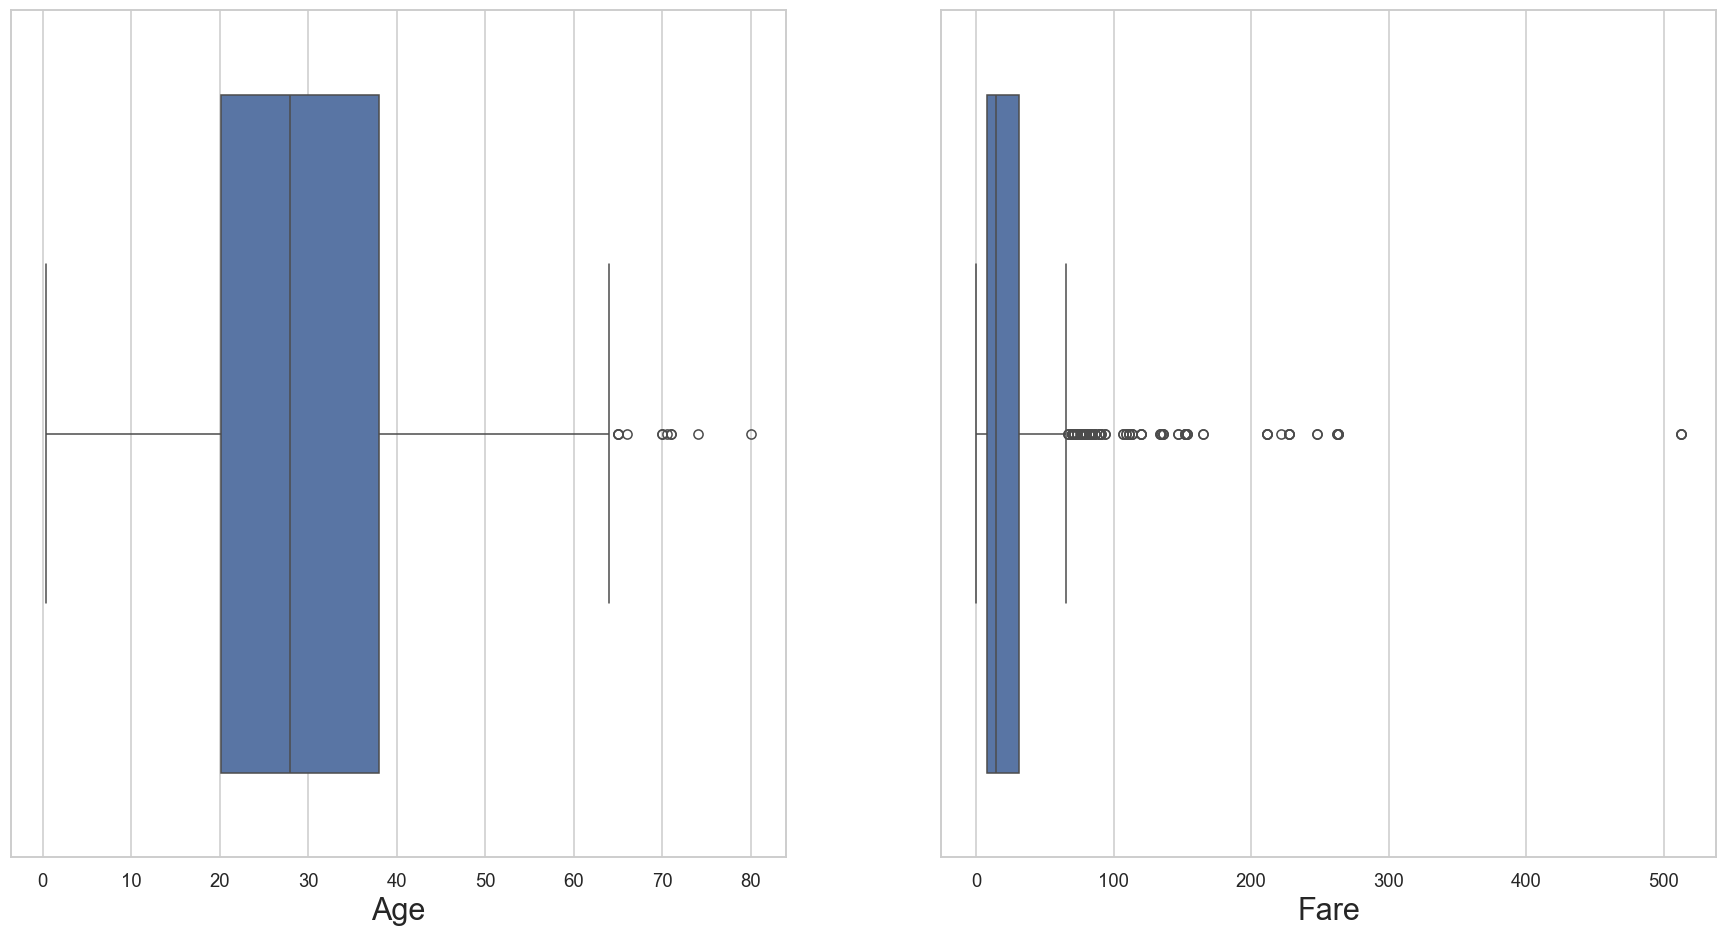

In [20]:

plt.subplot(121) ; sns.boxplot(x = X_train['Age'])
plt.subplot(122) ;sns.boxplot(x = X_train['Fare'])


In [21]:

def outliers(col,df):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean_iqr = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df_clean_iqr

X_clean = outliers("Age" , X_train)


In [22]:
X_clean.drop(columns="Cabin" , inplace=True)
X_clean.dropna(inplace = True)

C:\Users\risha\AppData\Local\Temp\ipykernel_23060\2891173636.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_clean.drop(columns="Cabin" , inplace=True)
C:\Users\risha\AppData\Local\Temp\ipykernel_23060\2891173636.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_clean.dropna(inplace = True)


In [23]:
from scipy.stats import ttest_ind

survived =     y_train[X_clean.index]==1
not_survived = y_train[X_clean.index]==0

gp1 = X_clean[survived]["Age_mean"] 
gp2 = X_clean[not_survived]["Age_mean"]

t_stat , pm = ttest_ind(gp1 , gp2)

gp1med = X_clean[survived]["Age_median"]
gp2med = X_clean[not_survived]["Age_median"]

t , pmed = ttest_ind(gp1med , gp2med)

In [24]:
y_train.corr(X_clean['Fare'] , method='spearman')

0.33900925111540203

In [25]:
imp_cols = ['Pclass' ,'Fare' ,'mem_on_board' , 'Age_median' , 'Embarked' , 'Sex'  ]

X_train.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'mem_on_board', 'Age_median',
       'Age_mean'],
      dtype='object')

In [26]:
X_clean = outliers('Fare' , X_clean)

<Axes: ylabel='Fare'>

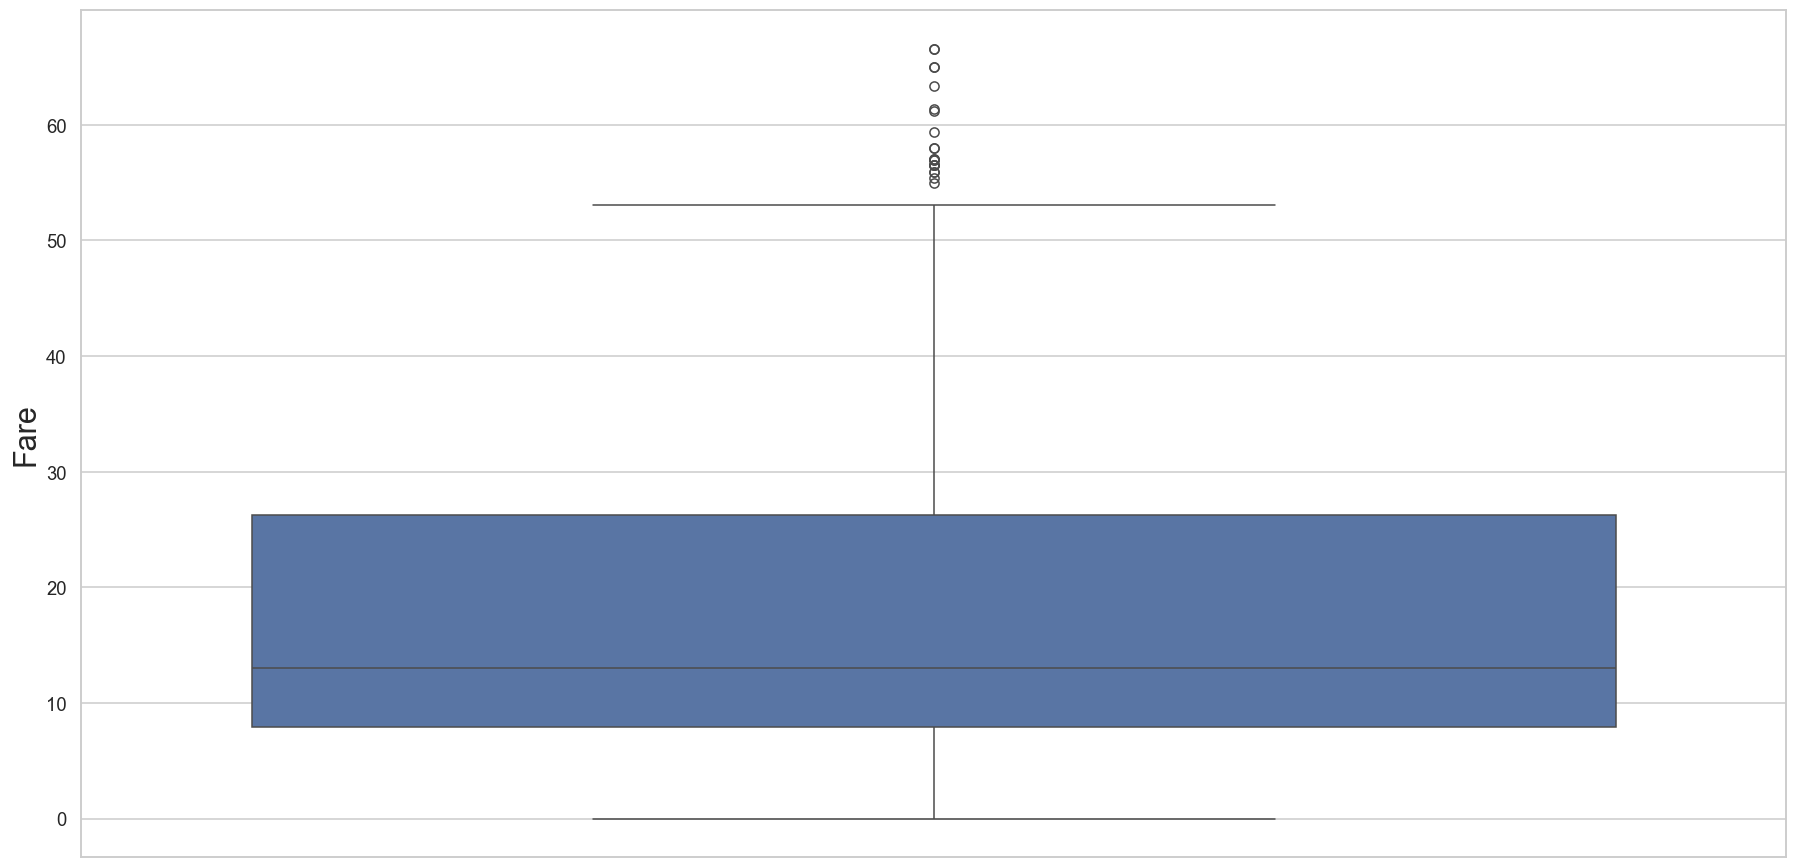

In [27]:
sns.boxplot(X_clean['Fare'])

In [28]:
y_train.corr(X_clean['Fare'], method='pearson')

0.23398198058316308

In [29]:
X_train[X_train["Pclass"] == 1]["Fare"].describe()
X_train[X_train["Fare"] >= 300]["Embarked"].value_counts()

Embarked
C    3
Name: count, dtype: int64

In [30]:
ct = pd.crosstab(X_train["Fare"] , X_train["Embarked"])
a ,pval,c ,d = chi2_contingency(ct)
pval

6.361671560484066e-121

<Axes: xlabel='Fare', ylabel='Count'>

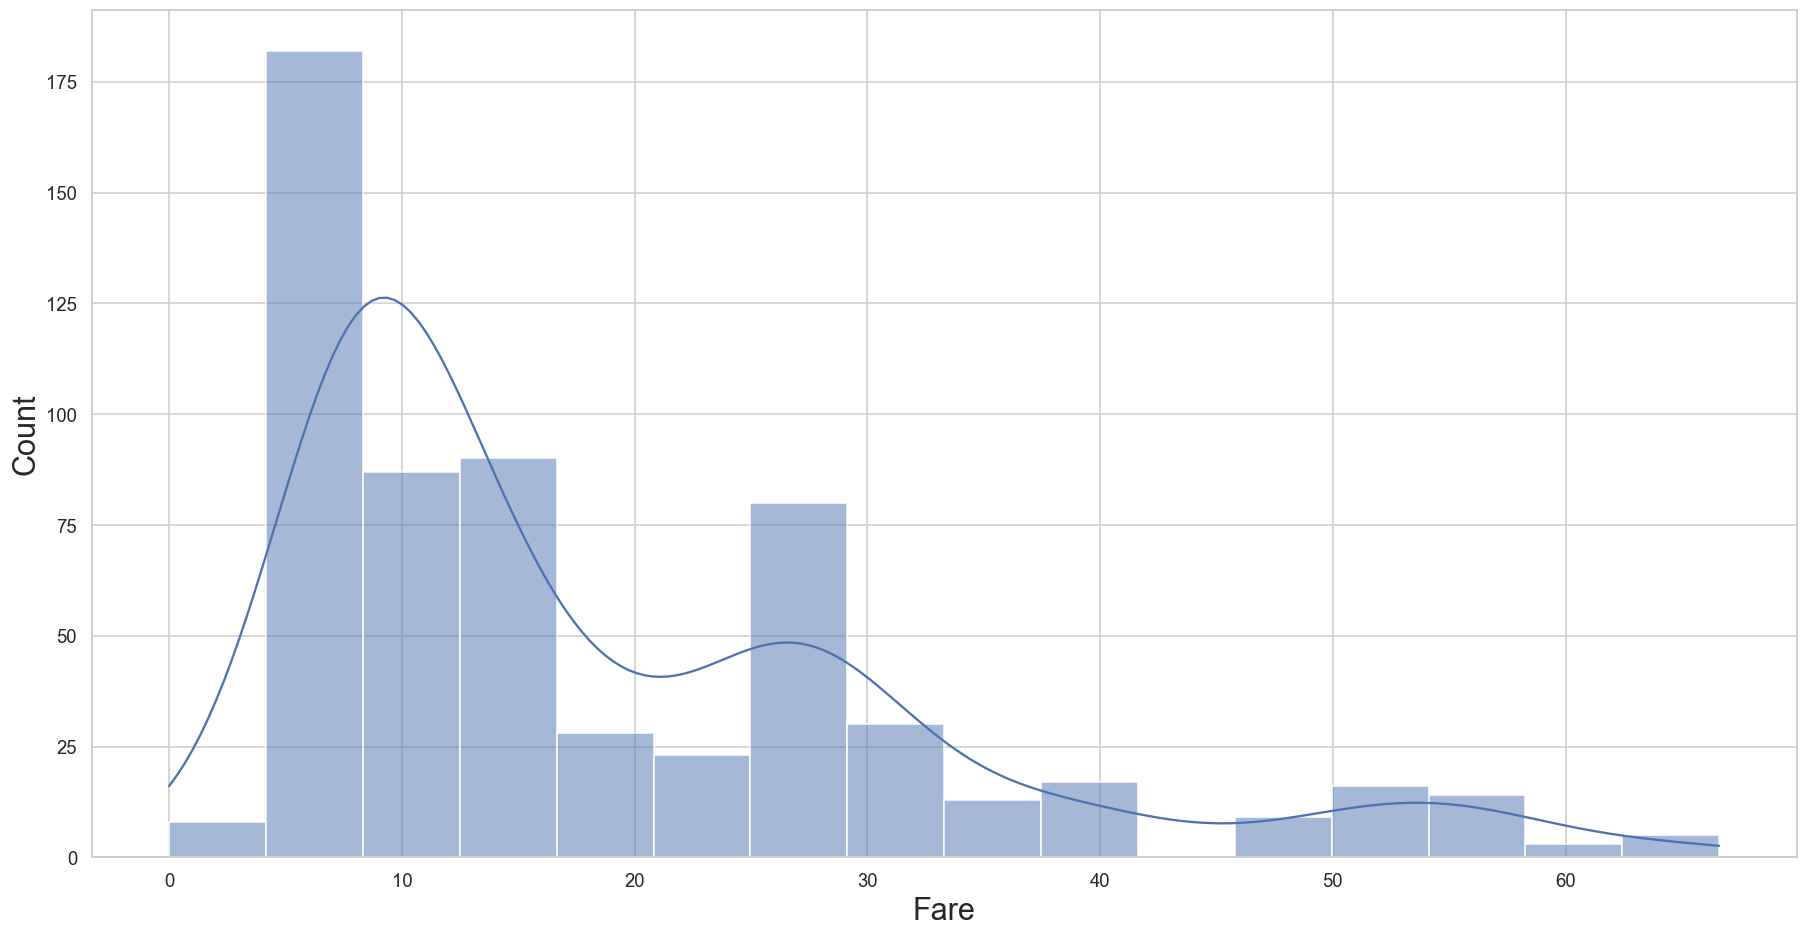

In [31]:
sns.histplot((X_clean["Fare"]) , kde = True)

In [32]:
len(X_train[X_train["Fare"] > 60])
y_train[X_train['Sex'] == 'female'].value_counts() # 

Survived
1    233
0     81
Name: count, dtype: int64

In [33]:
y_train[X_train['Sex'] == 'male'].value_counts()

Survived
0    468
1    109
Name: count, dtype: int64

In [34]:
X_train['SibSp'].describe()

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

In [35]:

y_train.corr(X_train["SibSp"] , method='pearson')
y_train.corr(X_train["SibSp"] , method='spearman')


0.08887948468090501

In [36]:
"cov(X ,Y)/ sqrt((var(X) * var(y)))"
"two options either discard the SibSp or take the mem_on_board"
X_train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [37]:
X_train[X_train['Embarked']=='C']['Fare'].describe()

count    168.000000
mean      59.954144
std       83.912994
min        4.012500
25%       13.697950
50%       29.700000
75%       78.500025
max      512.329200
Name: Fare, dtype: float64

In [38]:
X_train[X_train['Embarked']=='S']['Fare'].describe()

count    644.000000
mean      27.079812
std       35.887993
min        0.000000
25%        8.050000
50%       13.000000
75%       27.900000
max      263.000000
Name: Fare, dtype: float64

In [39]:
X_train[X_train['Embarked']=='Q']['Fare'].describe()

count    77.000000
mean     13.276030
std      14.188047
min       6.750000
25%       7.750000
50%       7.750000
75%      15.500000
max      90.000000
Name: Fare, dtype: float64

In [40]:
"if male are more then it is increasing or there is some other reason for the increase"
ct=  pd.crosstab(y_train , X_train['Sex'])
chi2 , p ,c ,d = chi2_contingency(ct)
p

1.1973570627755645e-58

In [41]:
y_train[X_train['Sex']=='male']
y_train[X_train['Sex']=='female']

1      1
2      1
3      1
8      1
9      1
      ..
880    1
882    0
885    0
887    1
888    0
Name: Survived, Length: 314, dtype: int64

In [42]:
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
cramers_v

0.5409359434469282

In [43]:
(X_train['Sex']=='male').sum() 

577

In [44]:
X_train_main = (X_train[imp_cols].dropna())


In [45]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(categories=[['C' ,'Q' ,'S'] , 
                                ['male' , 'female']] , sparse_output=False)
ohe.fit(X_train_main[['Embarked' , 'Sex']])
ohe.transform(X_train_main[['Embarked' , 'Sex']])


array([[0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       ...,
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 1., 0.]])

In [46]:
"We should standardize the age"


'We should standardize the age'

In [47]:
'''  
       dataset (removing waste cols and nan_values)
    /          \  
categorical   numerical
   |             |
   |             |
imputer(most   imputer(median)
frequent)        |   
   |             |
  ohe         standard scaler
   |             |
   \             /
    \           /
     \         /
     final_training Set


'''

'  \n       dataset (removing waste cols and nan_values)\n    /          \\  \ncategorical   numerical\n   |             |\n   |             |\nimputer(most   imputer(median)\nfrequent)        |   \n   |             |\n  ohe         standard scaler\n   |             |\n   \\             /\n    \\           /\n     \\         /\n     final_training Set\n\n\n'

In [48]:
X_train.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'mem_on_board', 'Age_median',
       'Age_mean'],
      dtype='object')

In [49]:

from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator , TransformerMixin
from sklearn.compose import ColumnTransformer

class Col_Attribute_Add(BaseEstimator , TransformerMixin):
    def __init__(self):
        return None
    
    def fit(self , X):
        return self 
    
    def transform(self , X):
        X['mem_on_board'] = X['SibSp'] + X['Parch']
        return X

num_pipeline = Pipeline(steps=(
    ('n_imputer' , SimpleImputer(strategy='median') ),
    ('scaler' , MinMaxScaler()),
))

cat_pipeline = Pipeline(steps=(
    ('cat_imputer' ,  SimpleImputer(strategy='most_frequent')),
    ('ohe' ,  OneHotEncoder()),
))

num_cat_cols = ['Pclass']
obj_cat_cols =  [ 'Embarked' , 'Sex']
transform_num_cols =  ['Fare' , 'Age' ]
transform_imp_cols = ['Pclass' ,'Fare' , 'Age' , 'Embarked' ,
                       'Sex' , 'SibSp' ,'Parch']
drop_cols = ['SibSp', 'Parch']


c_transform  =  ColumnTransformer(transformers = [   
    ('num_pipeline' , num_pipeline , transform_num_cols),
    ('cat_pipeline' , cat_pipeline , obj_cat_cols),
    # ('drop_cols' , 'drop' , drop_cols )
], remainder='passthrough')



final_pipeline = Pipeline(steps=(
    ('adder' , Col_Attribute_Add()),
    ('data_trans' , c_transform),   
))


X_transformed = final_pipeline.fit_transform(X_train[transform_imp_cols])

'''
haven't inherited  the base class's esitmator and transformermixin
'''


C:\Users\risha\AppData\Local\Temp\ipykernel_23060\630847547.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['mem_on_board'] = X['SibSp'] + X['Parch']


"\nhaven't inherited  the base class's esitmator and transformermixin\n"

In [50]:
X_transformed.shape

(891, 11)

In [51]:
X_transformed[0]

array([0.01415106, 0.27120388, 0.        , 0.        , 1.        ,
       0.        , 1.        , 3.        , 1.        , 0.        ,
       1.        ])

In [52]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=100 , C=1)
lr.fit(X_transformed , y_train)

LogisticRegression(C=1)

In [53]:
y_predict = lr.predict(X_transformed)
from sklearn.metrics import precision_score , recall_score ,roc_curve ,roc_auc_score
prec = precision_score(y_predict , y_train)
rec = recall_score(y_predict , y_train)
print("Prec:" , prec )
print("Rec:" , rec )
y_des = lr.decision_function(X_transformed)

Prec: 0.7017543859649122
Rec: 0.7619047619047619


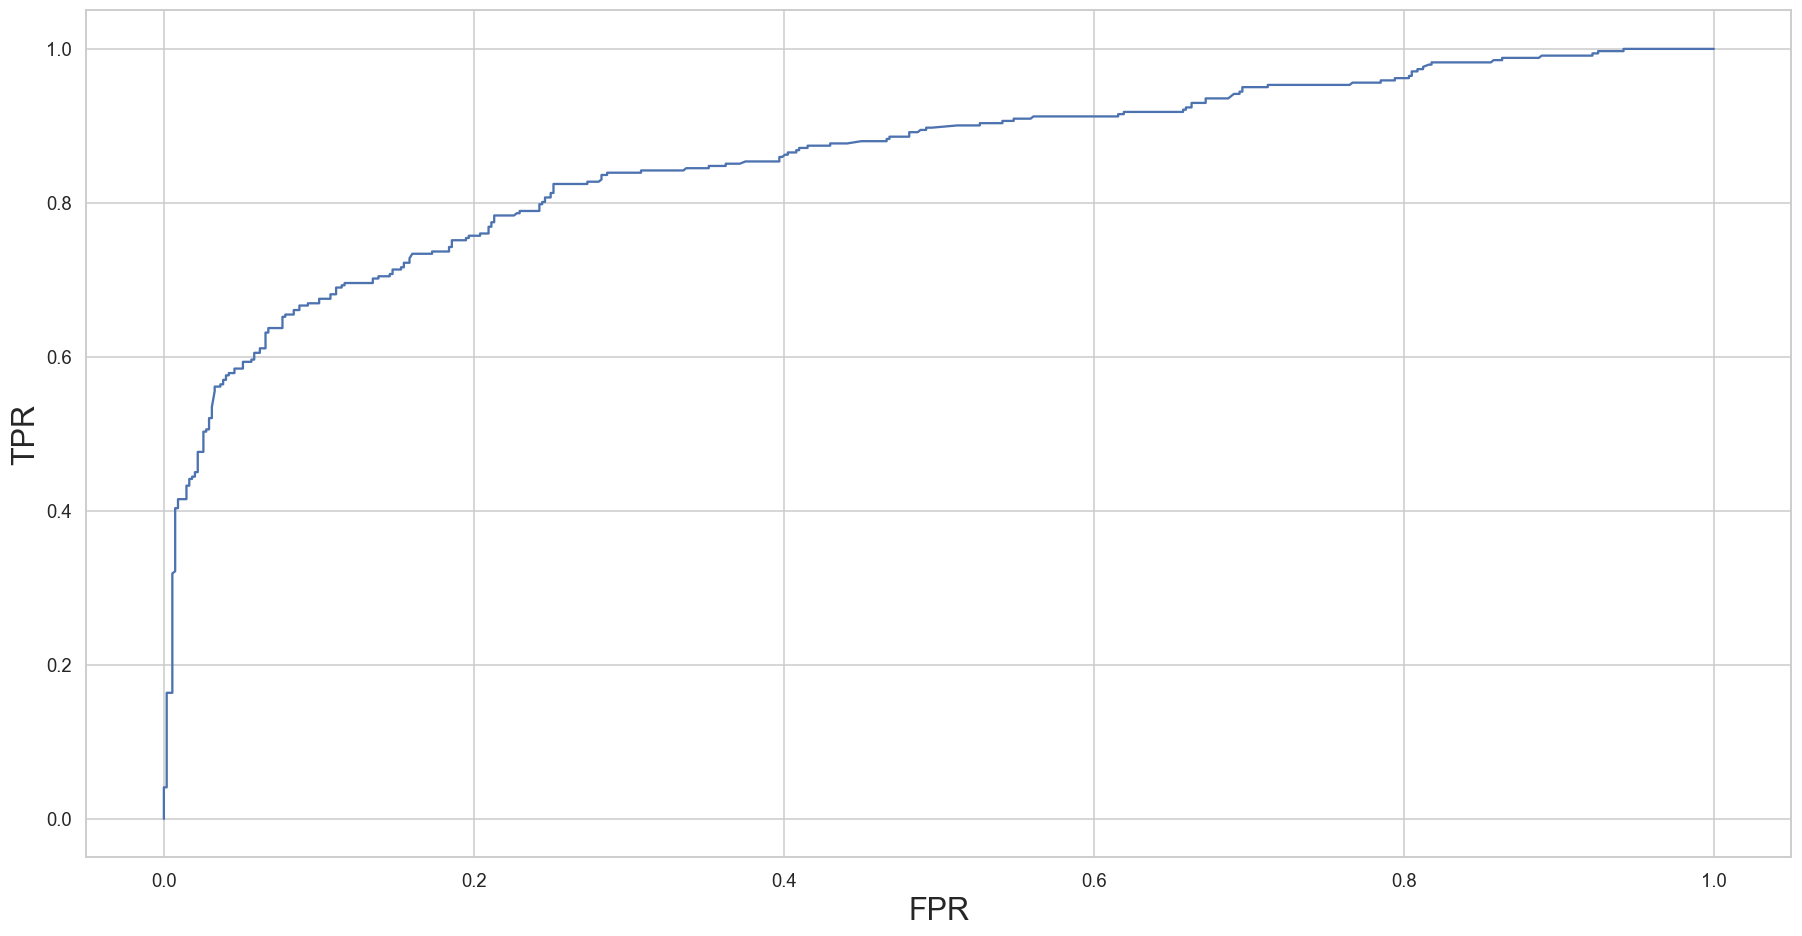

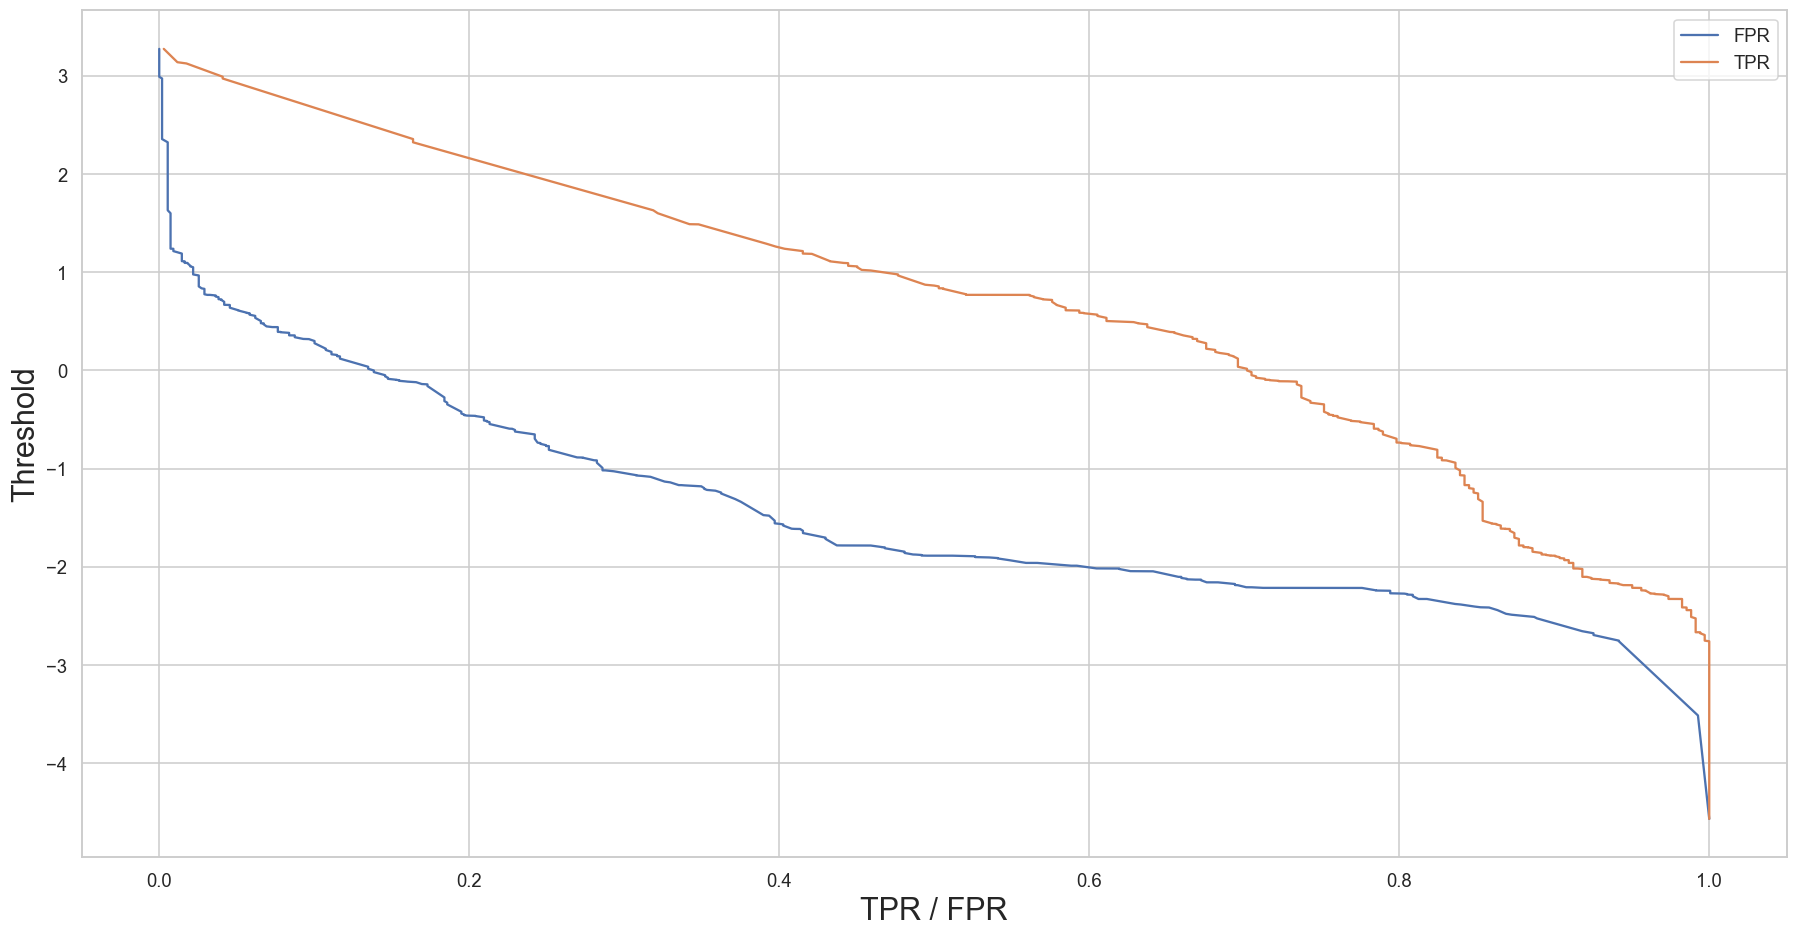

In [ ]:

fpr , tpr , threshold = roc_curve(y_train , y_des)
plt.plot(fpr , tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()
plt.plot(fpr, threshold , label = 'FPR')
plt.plot(tpr, threshold , label = 'TPR')
plt.legend()
plt.ylabel('Threshold')
plt.xlabel('TPR / FPR')
plt.show()

In [ ]:
arr = np.c_[(fpr, tpr)]
length = arr.shape[0]
area = 0

for i in range(length):
    x1 = arr[i][0]
    y1 = arr[i][1]
    x2 = arr[(i+1) % length][0]
    y2 = arr[(i+1) % length][1]
    area += x1*y2 - y1*x2


In [76]:
abs(area/2) + 0.5

0.8563975969066566

In [77]:
roc_auc_score(y_train , y_des)

0.8563975969066564

In [55]:
from sklearn.neighbors import KNeighborsClassifier
neighbour_clf = KNeighborsClassifier(n_neighbors= 5 , n_jobs = -1 
                                     , weights='distance')
neighbour_clf.fit(X_transformed , y_train)
y_neighbour_predict = neighbour_clf.predict(X_transformed)
prec = precision_score(y_neighbour_predict , y_train)
rec = recall_score(y_neighbour_predict , y_train)
print("Prec:" , prec )
print("Rec:" , rec )

Prec: 0.9532163742690059
Rec: 0.9939024390243902


In [ ]:

X_test_transform = final_pipeline.fit_transform(X_test[transform_imp_cols])

y_predict_test = neighbour_clf.predict(X_test_transform)
precision_score(y_predict_test , y_test)
recall_score(y_predict_test , y_test)


C:\Users\risha\AppData\Local\Temp\ipykernel_23060\630847547.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['mem_on_board'] = X['SibSp'] + X['Parch']


0.78

In [57]:
X_train['Age'][y_train==1].describe()

count    290.000000
mean      28.343678
std       14.950973
min        0.416700
25%       19.000000
50%       28.000000
75%       36.000000
max       80.000000
Name: Age, dtype: float64

In [58]:
X_train['Age'][y_train==0].describe()

count    424.000000
mean      30.626179
std       14.172110
min        1.000000
25%       21.000000
50%       28.000000
75%       39.000000
max       74.000000
Name: Age, dtype: float64

In [59]:
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(neighbour_clf , X_transformed , y_train ,cv =10)
cv_score.mean()

0.7778277153558053

In [60]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svm_clf = SVC()
svm_clf.fit(X_transformed , y_train)
cv = cross_val_score(svm_clf , X_transformed , y_train ,cv = 10)

cv.mean()

y_pred = svm_clf.predict(X_transformed)
acc = accuracy_score(y_pred, y_train)
prec = precision_score(y_pred , y_train)
acc

0.8114478114478114